# Agent 运行结果对比

读取 `runs/` 下的结果文件，按 **Model** 分组对比各 **Agent** 命中率。

- **baseline**：`runs/baseline_{model}.json`
- **m2**：`runs/m2_top{TOP_K}_{MODE}_{model}.json`
- 横轴：**Model**（如 `qwen-vl-max`）
- 每组内多根柱：**Baseline**、**M2 (top5, mid)**、**M2 (top10, mid)** 等各占一根
- 命中字段：优先 `hit`，兼容旧版 `correct`

In [43]:
import json
import re
from dataclasses import dataclass
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

RUNS_DIR = Path("runs")
INSTRUCTIONS_DIR = Path("AC_data/step_instructions")

# agent 家族排序（baseline 在前，m2 各变体紧随其后）
AGENT_FAMILY_ORDER = ["baseline", "m2"]

# None = 自动发现全部 model
MODELS = None

COLOR_BASELINE = "#B0BEC5"
M2_VARIANT_COLORS = ["#C8E6C9", "#81C784", "#66BB6A", "#43A047", "#2E7D32"]
DEFAULT_COLOR = "#90A4AE"

_RE_BASELINE = re.compile(r"^baseline_(?P<model>.+)$")
_RE_M2 = re.compile(r"^m2_top(?P<topk>\d+)_(?P<mode>worst|mid|best)_(?P<model>.+)$", re.I)
_RE_M2_LEGACY = re.compile(r"^m2_(?P<model>.+)$")


@dataclass(frozen=True)
class ParsedRun:
    series_key: str   # 图中一根柱的唯一 id，如 baseline / m2_top10_mid
    family: str       # baseline | m2
    model: str        # 真实 model，如 qwen-vl-max
    label: str
    top_k: int | None = None
    mode: str | None = None


def list_all_step_ins_stems() -> list[str]:
    return sorted(p.stem for p in INSTRUCTIONS_DIR.glob("*.txt"))


def is_hit(record: dict) -> bool:
    if "hit" in record:
        return bool(record["hit"])
    if "correct" in record:
        return bool(record["correct"])
    return False


def has_api_error(record: dict) -> bool:
    pred = record.get("prediction")
    return isinstance(pred, dict) and "error" in pred


def _label_from_config(family: str, top_k: int | None, mode: str | None) -> str:
    if family == "baseline":
        return "Baseline"
    if top_k is not None and mode is not None:
        return f"M2 (top{top_k}, {mode})"
    return "M2"


def parse_run_filename(path: Path) -> ParsedRun | None:
    if path.name == "comparison_report.json":
        return None
    stem = path.stem

    m = _RE_M2.match(stem)
    if m:
        top_k = int(m.group("topk"))
        mode = m.group("mode").lower()
        model = m.group("model")
        series_key = f"m2_top{top_k}_{mode}"
        return ParsedRun(
            series_key=series_key,
            family="m2",
            model=model,
            label=_label_from_config("m2", top_k, mode),
            top_k=top_k,
            mode=mode,
        )

    m = _RE_BASELINE.match(stem)
    if m:
        return ParsedRun(
            series_key="baseline",
            family="baseline",
            model=m.group("model"),
            label="Baseline",
        )

    m = _RE_M2_LEGACY.match(stem)
    if m:
        return ParsedRun(
            series_key="m2",
            family="m2",
            model=m.group("model"),
            label="M2",
        )

    return None


def series_sort_key(series_key: str) -> tuple:
    if series_key == "baseline":
        return (0, 0, "")
    m = re.match(r"^m2_top(\d+)_(worst|mid|best)$", series_key)
    if m:
        return (1, int(m.group(1)), m.group(2))
    if series_key.startswith("m2"):
        return (1, 999, series_key)
    return (2, 0, series_key)


def load_runs(runs_dir: Path, models: list[str] | None) -> dict[str, dict[str, dict]]:
    """返回 {model: {series_key: {"file", "records", "label", "family", ...}}}"""
    parsed_files: list[tuple[Path, ParsedRun]] = []
    for f in runs_dir.glob("*.json"):
        p = parse_run_filename(f)
        if p is not None:
            parsed_files.append((f, p))

    all_models = sorted({p.model for _, p in parsed_files})
    target_models = all_models if models is None else [m for m in models if m in all_models]

    result: dict[str, dict[str, dict]] = defaultdict(dict)
    for f, p in parsed_files:
        if p.model not in target_models:
            continue
        with open(f, "r", encoding="utf-8") as fh:
            records = json.load(fh)
        if not isinstance(records, list):
            continue
        result[p.model][p.series_key] = {
            "_file": f.name,
            "records": records,
            "label": p.label,
            "family": p.family,
            "top_k": p.top_k,
            "mode": p.mode,
        }
    return dict(result)


model_agent_results = load_runs(RUNS_DIR, MODELS)
models = sorted(model_agent_results.keys())

print(f"对比模型 ({len(models)}): {models}\n")
if not model_agent_results:
    print("未找到 runs/*.json，请先运行 main.py 生成结果。")
else:
    for model_name in models:
        agents = model_agent_results[model_name]
        print(f"MODEL: {model_name}")
        for series_key in sorted(agents.keys(), key=series_sort_key):
            v = agents[series_key]
            hits = sum(1 for r in v["records"] if is_hit(r))
            print(f"  {v['label']}: {v['_file']} ({len(v['records'])} 条, hit={hits})")
        print()

对比模型 (2): ['qwen-vl-max', 'qwen3-vl-flash']

MODEL: qwen-vl-max
  Baseline: baseline_qwen-vl-max.json (300 条, hit=241)
  M2 (top10, best): m2_top10_best_qwen-vl-max.json (300 条, hit=272)
  M2 (top10, worst): m2_top10_worst_qwen-vl-max.json (100 条, hit=82)
  M2 (top3, best): m2_top3_best_qwen-vl-max.json (300 条, hit=270)
  M2 (top5, best): m2_top5_best_qwen-vl-max.json (300 条, hit=273)

MODEL: qwen3-vl-flash
  Baseline: baseline_qwen3-vl-flash.json (100 条, hit=6)



In [44]:
# 汇总表：Model × Agent(series) 命中率
all_stats: list[dict] = []

for model_name in models:
    agents = model_agent_results.get(model_name, {})
    for series_key in sorted(agents.keys(), key=series_sort_key):
        v = agents[series_key]
        records = v["records"]
        total = len(records)
        hits = sum(1 for r in records if is_hit(r))
        misses = total - hits
        api_errors = sum(1 for r in records if has_api_error(r))
        accuracy = hits / total * 100 if total > 0 else 0.0
        all_stats.append({
            "Model": model_name,
            "SeriesKey": series_key,
            "Family": v["family"],
            "Agent": v["label"],
            "Total": total,
            "Hit": hits,
            "Miss": misses,
            "API_Errors": api_errors,
            "Accuracy_%": round(accuracy, 2),
        })

df = pd.DataFrame(all_stats)
if df.empty:
    print("暂无统计数据。")
else:
    display_cols = ["Model", "Agent", "Total", "Hit", "Miss", "API_Errors", "Accuracy_%"]
    print(df[display_cols].to_string(index=False))

         Model             Agent  Total  Hit  Miss  API_Errors  Accuracy_%
   qwen-vl-max          Baseline    300  241    59           0       80.33
   qwen-vl-max  M2 (top10, best)    300  272    28           0       90.67
   qwen-vl-max M2 (top10, worst)    100   82    18           0       82.00
   qwen-vl-max   M2 (top3, best)    300  270    30           0       90.00
   qwen-vl-max   M2 (top5, best)    300  273    27           0       91.00
qwen3-vl-flash          Baseline    100    6    94           0        6.00


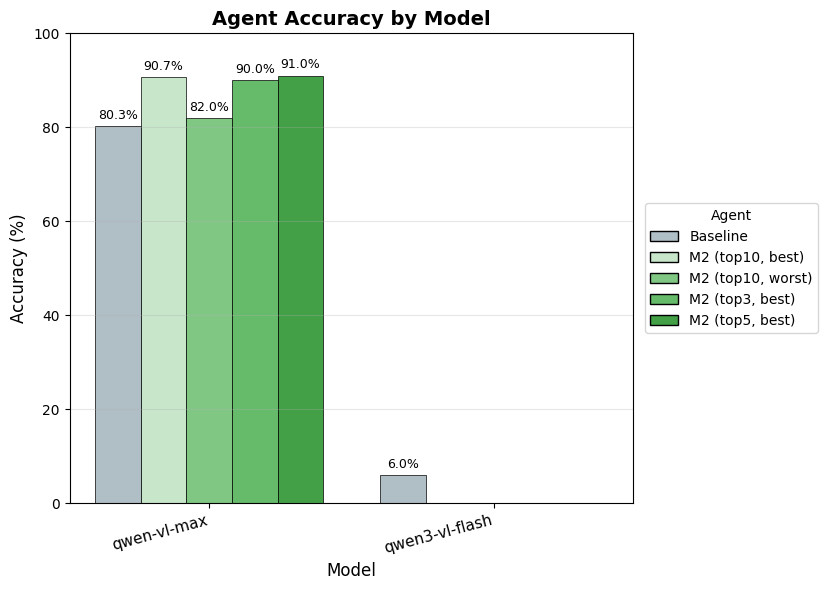

In [45]:
# 分组柱状图：横轴 Model，每组内 baseline + 各 m2_top{k}_{mode} 各占一根柱
if not all_stats:
    print("暂无统计数据，请先运行 main.py 生成 runs/*.json")
else:
    series_keys_in_chart = sorted(
        {s["SeriesKey"] for s in all_stats},
        key=series_sort_key,
    )
    key_to_label = {s["SeriesKey"]: s["Agent"] for s in all_stats}
    agents_order = [key_to_label[k] for k in series_keys_in_chart]

    chart_models = sorted(set(s["Model"] for s in all_stats))
    n_series = len(series_keys_in_chart)
    width = 0.8 / max(n_series, 1)

    m2_color_idx = 0
    series_colors = []
    for sk in series_keys_in_chart:
        if sk == "baseline":
            series_colors.append(COLOR_BASELINE)
        elif sk.startswith("m2"):
            series_colors.append(M2_VARIANT_COLORS[m2_color_idx % len(M2_VARIANT_COLORS)])
            m2_color_idx += 1
        else:
            series_colors.append(DEFAULT_COLOR)

    fig_w = max(8, 4 + len(chart_models) * 2.2)
    fig, ax = plt.subplots(figsize=(fig_w, 6))

    for i, series_key in enumerate(series_keys_in_chart):
        acc_map = {
            s["Model"]: s["Accuracy_%"]
            for s in all_stats if s["SeriesKey"] == series_key
        }
        accs = [acc_map.get(m, 0) for m in chart_models]
        x_pos = [
            j + i * width - (n_series - 1) * width / 2
            for j in range(len(chart_models))
        ]
        bars = ax.bar(
            x_pos,
            accs,
            width,
            label=key_to_label[series_key],
            color=series_colors[i],
            edgecolor="black",
            linewidth=0.5,
        )
        for bar, acc in zip(bars, accs):
            if acc <= 0:
                continue
            h = bar.get_height()
            ax.annotate(
                f"{acc:.1f}%",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    ax.set_xticks(range(len(chart_models)))
    ax.set_xticklabels(chart_models, fontsize=11, rotation=15, ha="right")
    ax.set_ylabel("Accuracy (%)", fontsize=12)
    ax.set_xlabel("Model", fontsize=12)
    ax.set_title("Agent Accuracy by Model", fontsize=14, fontweight="bold")
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3)

    legend_patches = [
        Patch(facecolor=series_colors[i], edgecolor="black", label=agents_order[i])
        for i in range(n_series)
    ]
    ax.legend(
        handles=legend_patches,
        title="Agent",
        fontsize=10,
        bbox_to_anchor=(1.02, 0.5),
        loc="center left",
        borderaxespad=0.0,
    )
    plt.tight_layout()
    plt.show()

In [46]:
# 透视表：行=Model，列=Agent，值=Accuracy_%
if not df.empty:
    pivot = df.pivot(index="Model", columns="Agent", values="Accuracy_%")
    print("命中率透视表 (%):\n")
    print(pivot.to_string(float_format=lambda x: f"{x:.2f}"))
else:
    print("暂无数据。")

命中率透视表 (%):

Agent           Baseline  M2 (top10, best)  M2 (top10, worst)  M2 (top3, best)  M2 (top5, best)
Model                                                                                          
qwen-vl-max        80.33             90.67              82.00            90.00            91.00
qwen3-vl-flash      6.00               NaN                NaN              NaN              NaN


In [47]:
# Case Study：Baseline 命中但某 M2 变体未命中
_all_stems = list_all_step_ins_stems()
_stem_to_index = {stem: idx for idx, stem in enumerate(_all_stems)}


def collect_sample_hits(agents: dict) -> dict[str, dict[str, bool]]:
    sample_hits: dict[str, dict[str, bool]] = defaultdict(dict)
    for series_key, v in agents.items():
        label = v["label"]
        for r in v["records"]:
            sid = r.get("sample_id")
            if sid:
                sample_hits[sid][label] = is_hit(r)
    return dict(sample_hits)


print("=" * 60)
print("Case Study：Baseline 命中但 M2 变体未命中")
print("=" * 60)

for model_name in models:
    agents = model_agent_results.get(model_name, {})
    if "baseline" not in agents:
        print(f"\nModel: {model_name} — 缺少 baseline，跳过")
        continue

    baseline_label = agents["baseline"]["label"]
    m2_series = [k for k in agents if k.startswith("m2")]
    if not m2_series:
        print(f"\nModel: {model_name} — 缺少 m2 变体，跳过")
        continue

    sample_hits = collect_sample_hits(agents)
    print(f"\nModel: {model_name}")
    print(f"  共有样本: {len(sample_hits)}")

    for series_key in sorted(m2_series, key=series_sort_key):
        m2_label = agents[series_key]["label"]
        regressions = []
        for sid, hits in sorted(sample_hits.items()):
            if hits.get(baseline_label) and not hits.get(m2_label):
                regressions.append(_stem_to_index.get(sid, sid))
        print(f"  Baseline✓ & {m2_label}✗: {len(regressions)} 个")
        if regressions:
            preview = regressions[:20]
            suffix = " ..." if len(regressions) > 20 else ""
            print(f"    下标/ID: {preview}{suffix}")

print("\n" + "=" * 60)

Case Study：Baseline 命中但 M2 变体未命中

Model: qwen-vl-max
  共有样本: 300
  Baseline✓ & M2 (top10, best)✗: 14 个
    下标/ID: [11, 68, 99, 117, 148, 149, 163, 181, 187, 211, 249, 263, 286, 296]
  Baseline✓ & M2 (top10, worst)✗: 178 个
    下标/ID: [1, 5, 11, 22, 24, 31, 37, 68, 89, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109] ...
  Baseline✓ & M2 (top3, best)✗: 17 个
    下标/ID: [11, 15, 22, 68, 99, 117, 148, 149, 179, 180, 181, 187, 249, 258, 263, 289, 291]
  Baseline✓ & M2 (top5, best)✗: 17 个
    下标/ID: [11, 15, 22, 68, 99, 117, 163, 179, 181, 187, 198, 211, 249, 258, 263, 286, 291]

Model: qwen3-vl-flash — 缺少 m2 变体，跳过



In [48]:
report = {
    "agent_family_order": AGENT_FAMILY_ORDER,
    "models": models,
    "stats": all_stats,
}
RUNS_DIR.mkdir(parents=True, exist_ok=True)
report_path = RUNS_DIR / "comparison_report.json"
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)
print(f"对比报告已保存: {report_path}")

对比报告已保存: runs/comparison_report.json
